# 01 — Exploratory Data Analysis (EDA)

**Judul Penelitian:** Eksperimen Klasifikasi Depresi pada Remaja: Analisis Dampak Preprocessing dan Class Imbalance pada Model K-NN dan Random Forest

**Tujuan notebook ini:**
- Memahami struktur dan kualitas data
- Menganalisis distribusi fitur numerik dan kategorikal
- Mengeksplorasi class imbalance pada `depression_label`
- Mengidentifikasi korelasi antar fitur
- Mendeteksi potensi outlier sebelum preprocessing

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path('..').resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'Teen_Mental_Health_Dataset.csv'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print('Project root :', PROJECT_ROOT)
print('Dataset path :', DATA_PATH)
print('Figures dir  :', FIGURES_DIR)

Project root : C:\Users\Nafan\Documents\Learn & Project\Kuliah\PM\Tugas Akhir\eksperimen-klasifikasi-depresi
Dataset path : C:\Users\Nafan\Documents\Learn & Project\Kuliah\PM\Tugas Akhir\eksperimen-klasifikasi-depresi\data\Teen_Mental_Health_Dataset.csv
Figures dir  : C:\Users\Nafan\Documents\Learn & Project\Kuliah\PM\Tugas Akhir\eksperimen-klasifikasi-depresi\results\figures


In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]} baris x {df.shape[1]} kolom')
df.head()

Shape: 1500 baris x 13 kolom


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,13,male,7.2,TikTok,4.1,1.3,2.49,1.8,medium,5,5,4,0
1,16,female,7.1,TikTok,5.5,1.1,2.11,0.3,medium,7,10,7,1
2,17,female,5.5,TikTok,7.9,1.6,2.78,0.3,low,5,9,7,0
3,18,male,7.2,Both,4.4,3.0,2.29,1.4,low,9,9,3,1
4,14,male,2.5,TikTok,5.6,2.9,2.24,0.5,low,3,9,5,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1500 non-null   int64  
 1   gender                    1500 non-null   object 
 2   daily_social_media_hours  1500 non-null   float64
 3   platform_usage            1500 non-null   object 
 4   sleep_hours               1500 non-null   float64
 5   screen_time_before_sleep  1500 non-null   float64
 6   academic_performance      1500 non-null   float64
 7   physical_activity         1500 non-null   float64
 8   social_interaction_level  1500 non-null   object 
 9   stress_level              1500 non-null   int64  
 10  anxiety_level             1500 non-null   int64  
 11  addiction_level           1500 non-null   int64  
 12  depression_label          1500 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 152.5+ KB


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
if missing.any():
    display(missing_df[missing_df['missing_count'] > 0])
else:
    print('Tidak ada missing values.')

Tidak ada missing values.


In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
target_col = 'depression_label'
feature_numeric = [c for c in numeric_cols if c != target_col]

desc = df[feature_numeric].describe().T
desc['skew'] = df[feature_numeric].skew()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
age,1500.0,15.90,2.02,13.0,14.0,16.0,18.00,19.0,0.04
daily_social_media_hours,1500.0,4.71,2.04,1.0,3.0,4.8,6.50,8.0,-0.10
sleep_hours,1500.0,6.31,1.46,4.0,5.0,6.3,7.50,9.0,0.13
screen_time_before_sleep,1500.0,1.74,0.73,0.5,1.1,1.7,2.40,3.0,-0.00
academic_performance,1500.0,2.99,0.58,2.0,2.5,3.0,3.49,4.0,-0.00
physical_activity,1500.0,1.00,0.58,0.0,0.5,1.0,1.50,2.0,-0.06
stress_level,1500.0,5.70,2.94,1.0,3.0,6.0,8.00,10.0,-0.09
anxiety_level,1500.0,5.83,2.87,1.0,3.0,6.0,8.00,10.0,-0.14
addiction_level,1500.0,5.53,2.90,1.0,3.0,6.0,8.00,10.0,-0.02


Distribusi depression_label:
  0 (Tidak Terindikasi): 1350 sampel (90.0%)
  1 (Terindikasi Depresi): 150 sampel (10.0%)


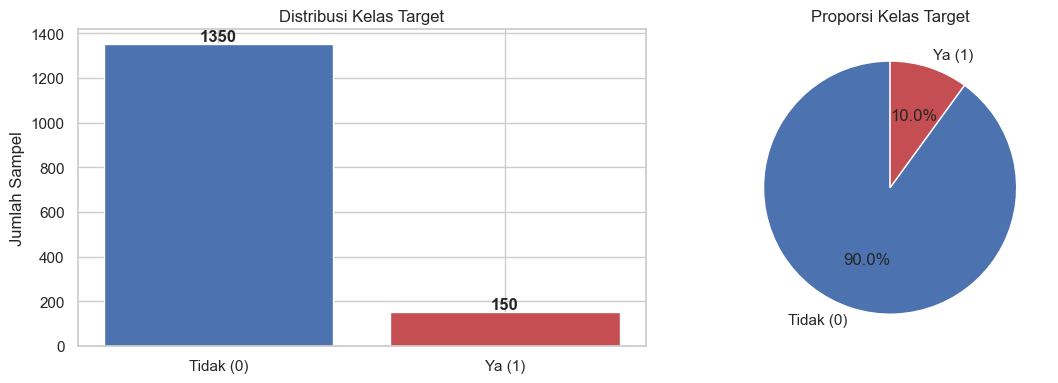

In [6]:
label_counts = df[target_col].value_counts().sort_index()
label_pct = (label_counts / len(df) * 100).round(2)

print('Distribusi depression_label:')
for label, count in label_counts.items():
    label_name = 'Terindikasi Depresi' if label == 1 else 'Tidak Terindikasi'
    print(f'  {label} ({label_name}): {count} sampel ({label_pct[label]}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4C72B0', '#C44E52']
bars = axes[0].bar(['Tidak (0)', 'Ya (1)'], label_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Distribusi Kelas Target')
axes[0].set_ylabel('Jumlah Sampel')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15, str(val), ha='center', fontweight='bold')

axes[1].pie(label_counts.values, labels=['Tidak (0)', 'Ya (1)'], autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Kelas Target')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_class_distribution.png', bbox_inches='tight')
plt.show()

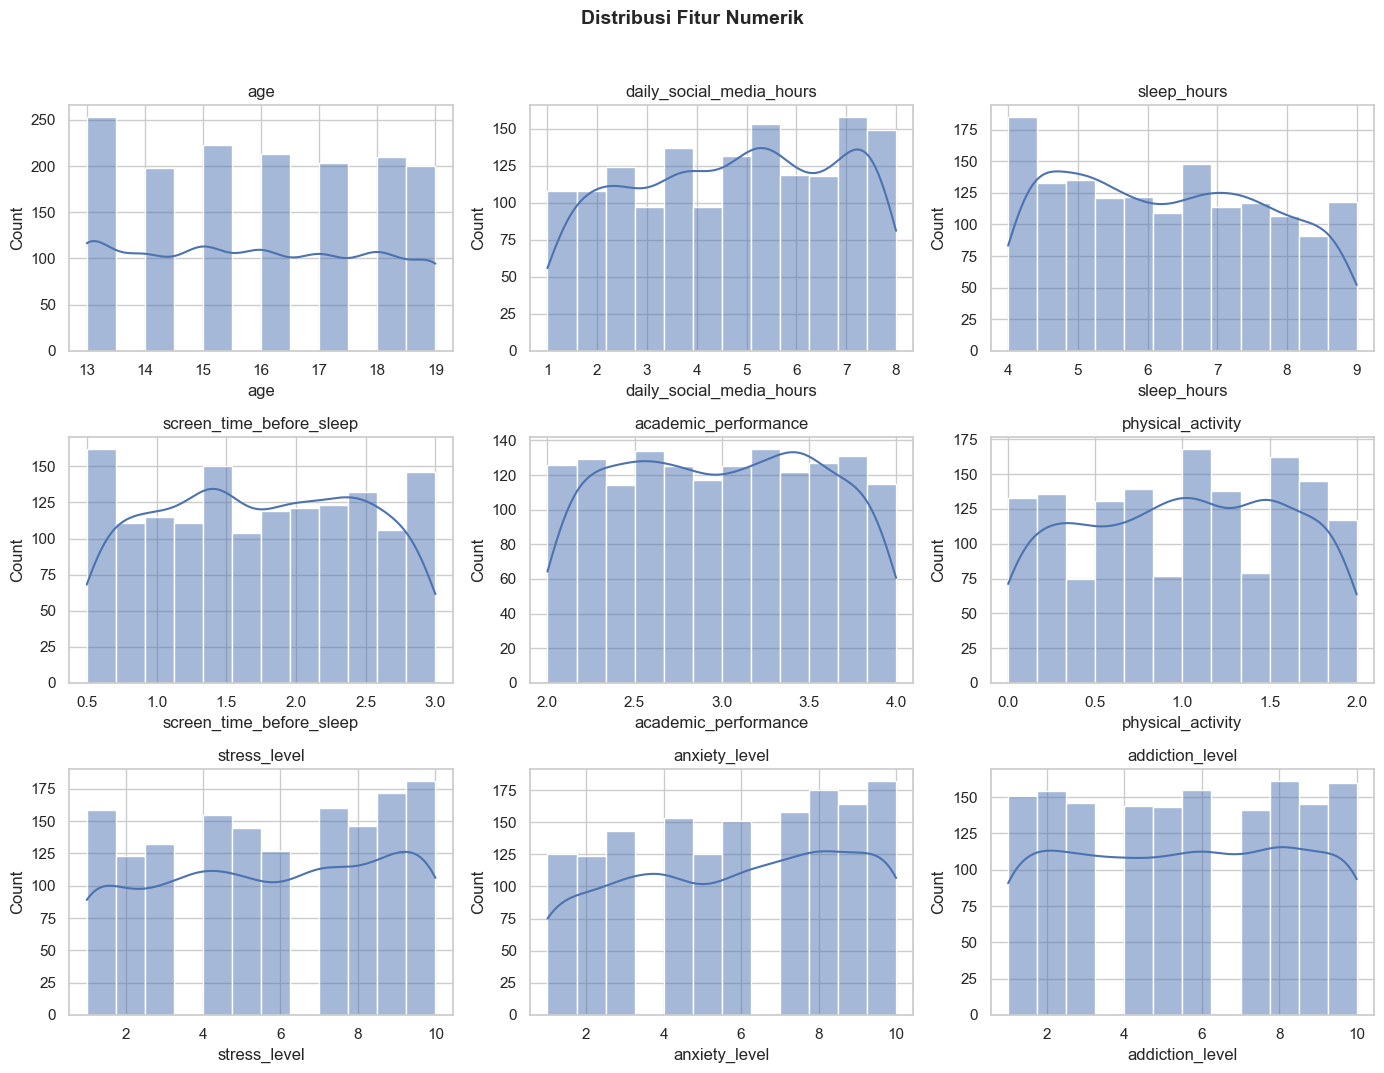

In [7]:
n_cols = 3
n_rows = int(np.ceil(len(feature_numeric) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(feature_numeric):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C72B0', edgecolor='white')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribusi Fitur Numerik', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_numeric_distributions.png', bbox_inches='tight')
plt.show()

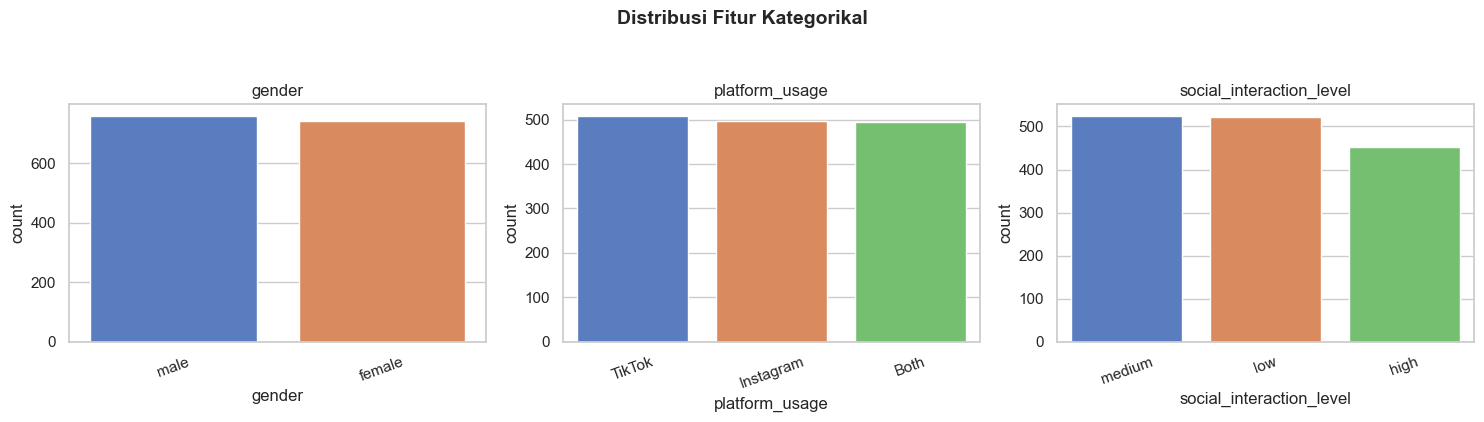

In [8]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette='muted', edgecolor='white')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Distribusi Fitur Kategorikal', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_categorical_distributions.png', bbox_inches='tight')
plt.show()

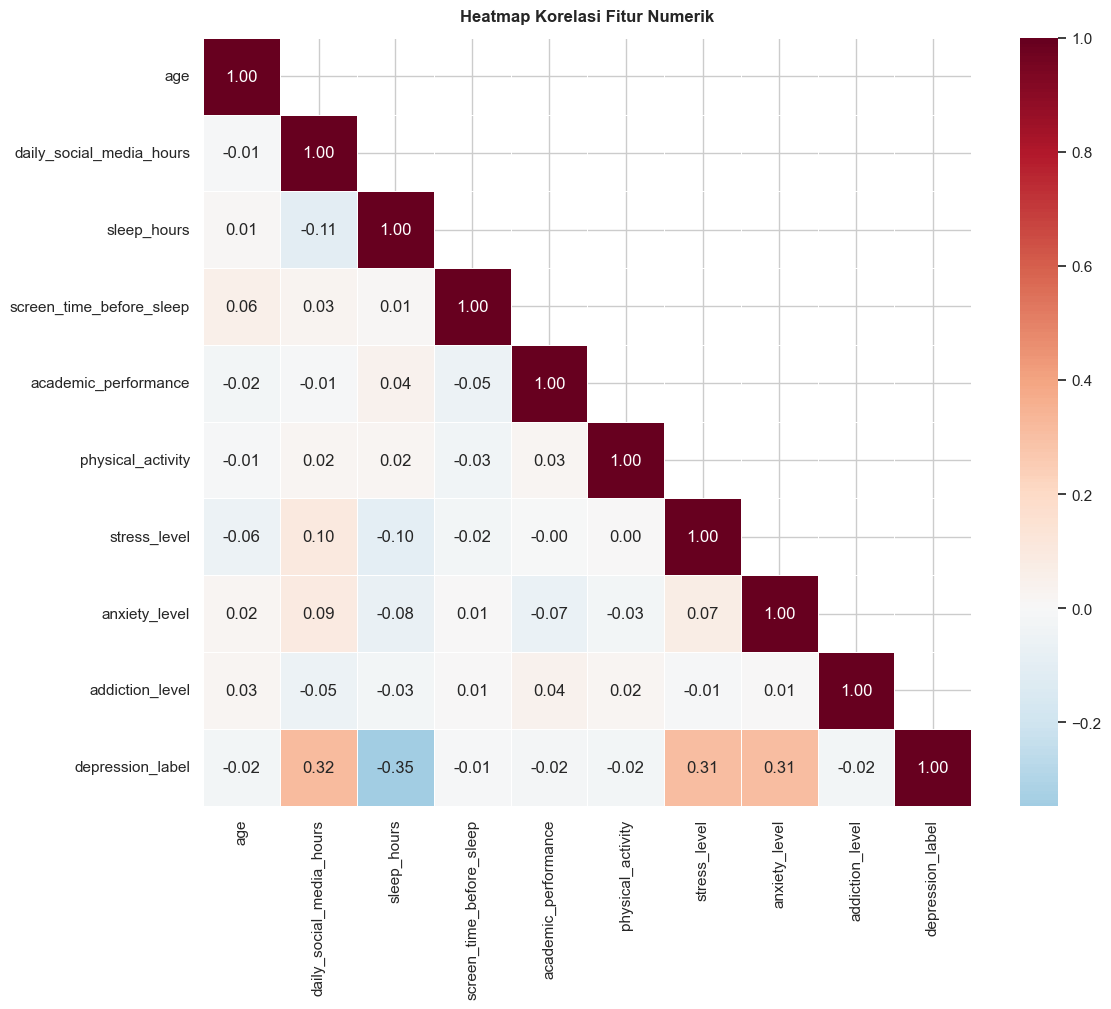

In [9]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', pad=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

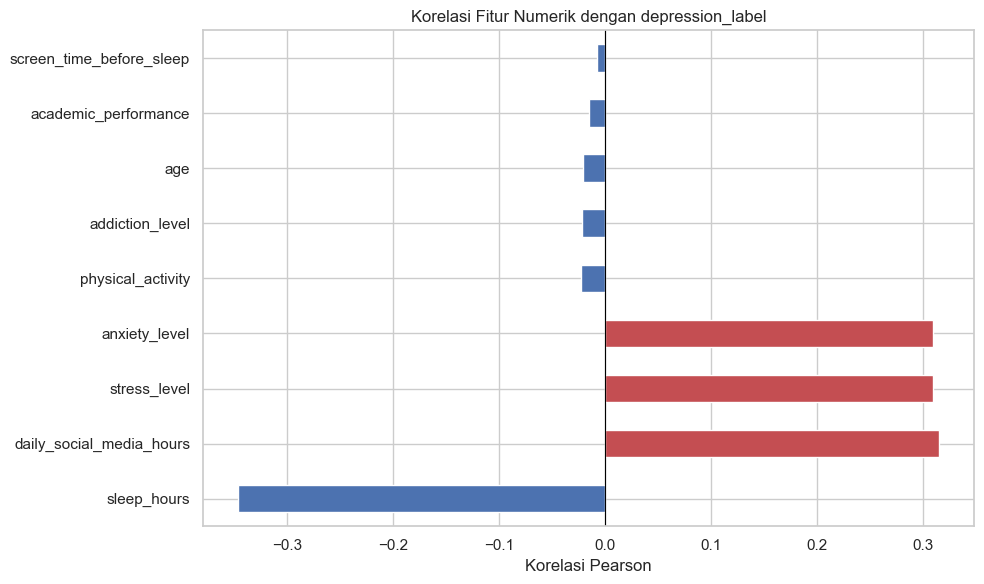

,correlation
sleep_hours,-0.346
daily_social_media_hours,0.315
stress_level,0.310
anxiety_level,0.309
physical_activity,-0.023
addiction_level,-0.022
age,-0.020
academic_performance,-0.016
screen_time_before_sleep,-0.008


In [10]:
target_corr = df[numeric_cols].corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur Numerik dengan depression_label')
plt.xlabel('Korelasi Pearson')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_target_correlation.png', bbox_inches='tight')
plt.show()

target_corr.to_frame('correlation').round(3)

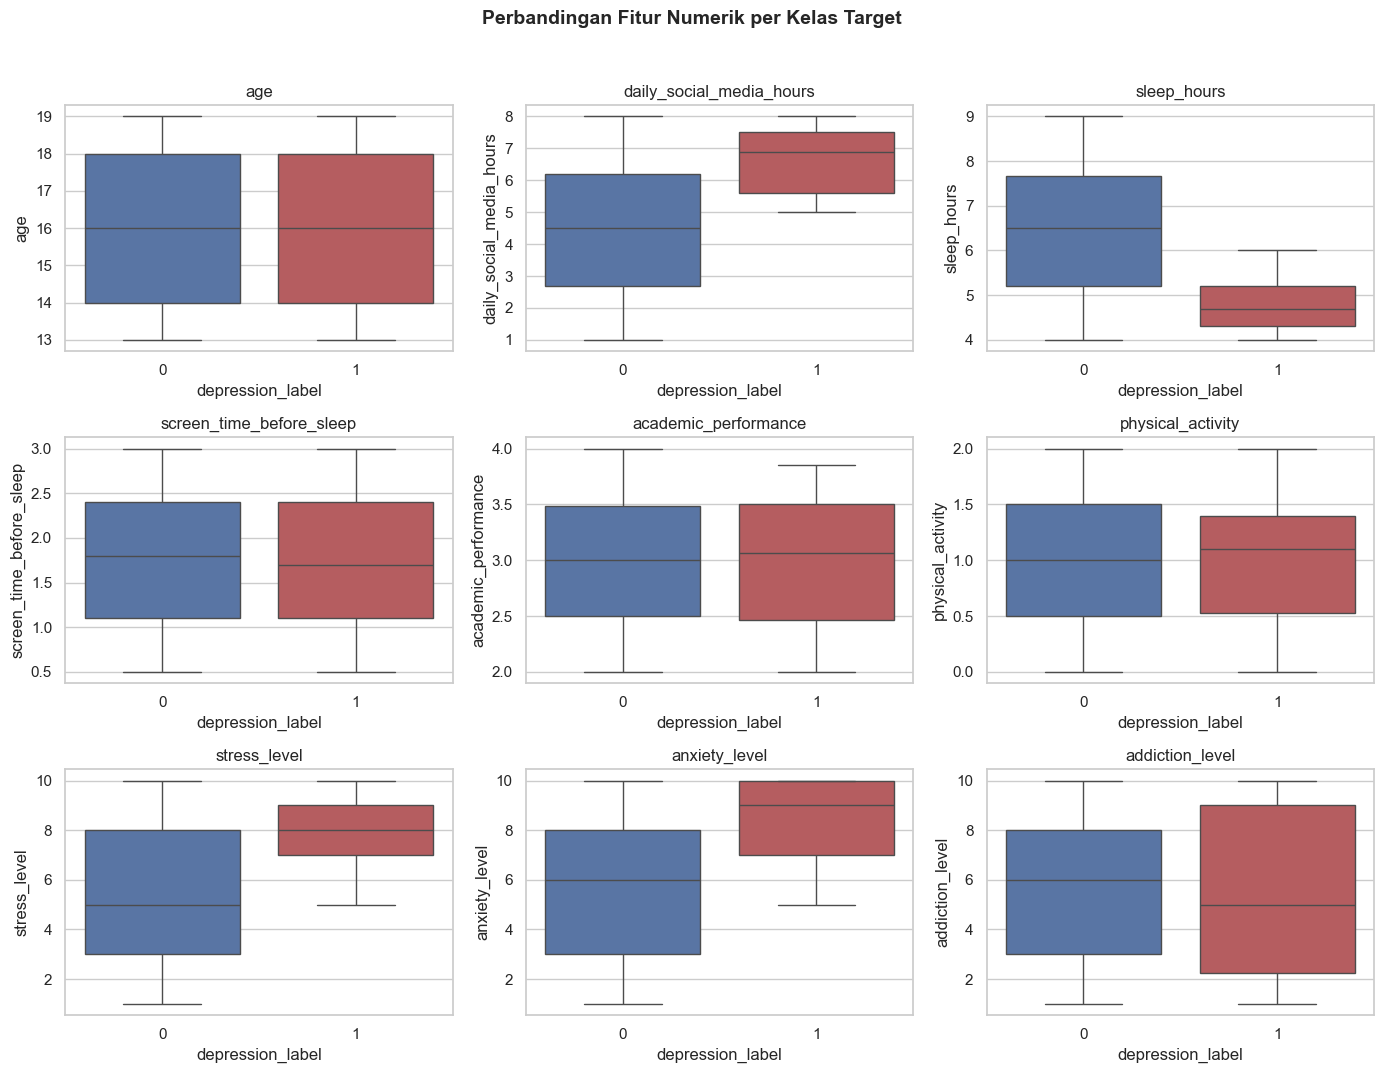

In [11]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(feature_numeric):
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[i], palette=['#4C72B0', '#C44E52'])
    axes[i].set_title(col)
    axes[i].set_xlabel('depression_label')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Perbandingan Fitur Numerik per Kelas Target', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_numeric_by_target.png', bbox_inches='tight')
plt.show()

In [12]:
mean_by_class = df.groupby(target_col)[feature_numeric].mean().T
mean_by_class.columns = ['Tidak Depresi (0)', 'Depresi (1)']
mean_by_class['Selisih (1-0)'] = mean_by_class['Depresi (1)'] - mean_by_class['Tidak Depresi (0)']
mean_by_class.round(2)

,Tidak Depresi (0),Depresi (1),Selisih (1-0)
age,15.91,15.77,-0.14
daily_social_media_hours,4.49,6.64,2.15
sleep_hours,6.48,4.80,-1.68
screen_time_before_sleep,1.74,1.73,-0.02
academic_performance,3.00,2.97,-0.03
physical_activity,1.01,0.97,-0.04
stress_level,5.40,8.43,3.03
anxiety_level,5.54,8.49,2.96
addiction_level,5.55,5.34,-0.21


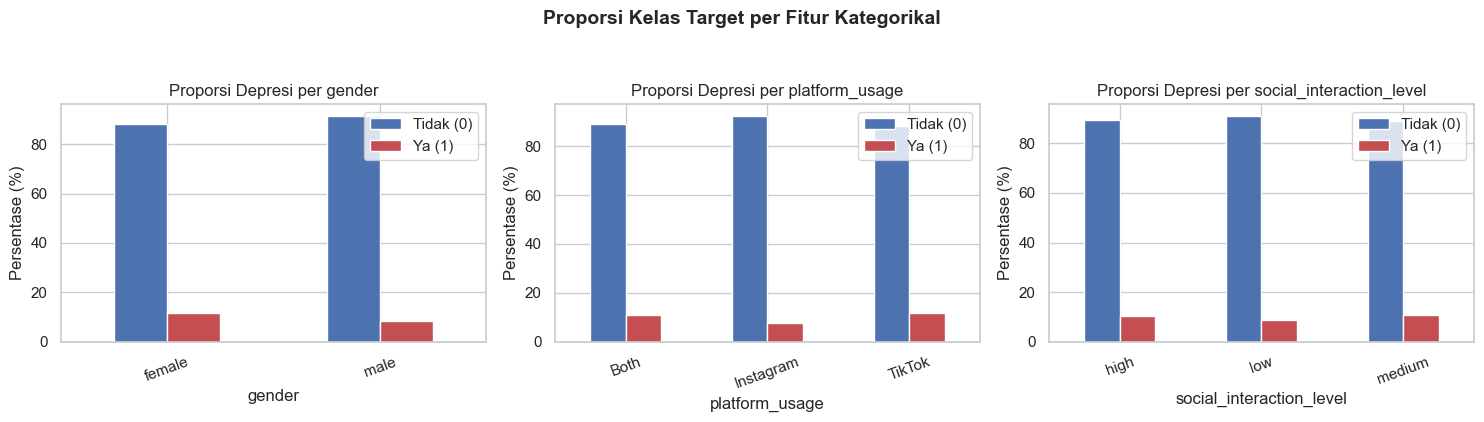

In [13]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df[target_col], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'], edgecolor='white')
    ax.set_title(f'Proporsi Depresi per {col}')
    ax.set_ylabel('Persentase (%)')
    ax.set_xlabel(col)
    ax.legend(['Tidak (0)', 'Ya (1)'])
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Proporsi Kelas Target per Fitur Kategorikal', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_categorical_vs_target.png', bbox_inches='tight')
plt.show()

In [14]:
outlier_summary = []

for col in feature_numeric:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'fitur': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'batas_bawah': round(lower, 2),
        'batas_atas': round(upper, 2),
        'jumlah_outlier': len(outliers),
        'pct_outlier': round(len(outliers) / len(df) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,fitur,Q1,Q3,IQR,batas_bawah,batas_atas,jumlah_outlier,pct_outlier
0,age,14.0,18.00,4.00,8.00,24.00,0,0.0
1,daily_social_media_hours,3.0,6.50,3.50,-2.25,11.75,0,0.0
2,sleep_hours,5.0,7.50,2.50,1.25,11.25,0,0.0
3,screen_time_before_sleep,1.1,2.40,1.30,-0.85,4.35,0,0.0
4,academic_performance,2.5,3.49,0.99,1.01,4.98,0,0.0
5,physical_activity,0.5,1.50,1.00,-1.00,3.00,0,0.0
6,stress_level,3.0,8.00,5.00,-4.50,15.50,0,0.0
7,anxiety_level,3.0,8.00,5.00,-4.50,15.50,0,0.0
8,addiction_level,3.0,8.00,5.00,-4.50,15.50,0,0.0


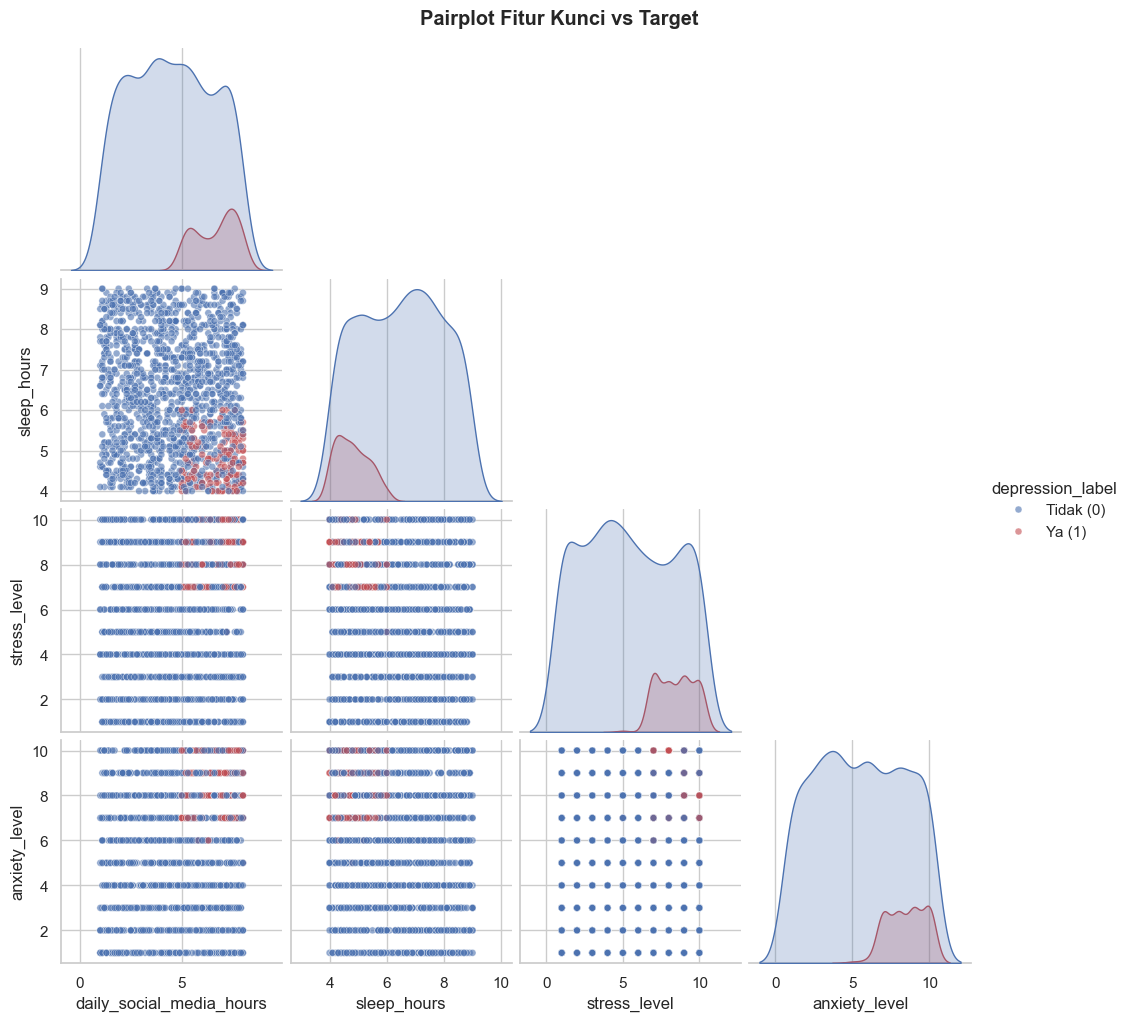

In [15]:
key_features = ['daily_social_media_hours', 'sleep_hours', 'stress_level', 'anxiety_level', target_col]
sample_df = df[key_features].copy()
sample_df[target_col] = sample_df[target_col].map({0: 'Tidak (0)', 1: 'Ya (1)'})

g = sns.pairplot(
    sample_df,
    hue=target_col,
    palette={'Tidak (0)': '#4C72B0', 'Ya (1)': '#C44E52'},
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 25},
)
g.fig.suptitle('Pairplot Fitur Kunci vs Target', y=1.02, fontweight='bold')
plt.savefig(FIGURES_DIR / '08_pairplot_key_features.png', bbox_inches='tight')
plt.show()

In [16]:
desc.to_csv(TABLES_DIR / '01_descriptive_statistics.csv')
mean_by_class.to_csv(TABLES_DIR / '02_mean_by_class.csv')
outlier_df.to_csv(TABLES_DIR / '03_outlier_summary.csv', index=False)
target_corr.to_frame('correlation').to_csv(TABLES_DIR / '04_target_correlation.csv')

label_summary = pd.DataFrame({
    'label': label_counts.index,
    'count': label_counts.values,
    'percentage': label_pct.values,
})
label_summary.to_csv(TABLES_DIR / '05_class_distribution.csv', index=False)

print('Tabel ringkasan disimpan di:', TABLES_DIR)

Tabel ringkasan disimpan di: C:\Users\Nafan\Documents\Learn & Project\Kuliah\PM\Tugas Akhir\eksperimen-klasifikasi-depresi\results\tables


## Ringkasan Temuan EDA

Berdasarkan eksplorasi data di atas, berikut poin-poin utama yang relevan untuk tahap preprocessing dan eksperimen:

1. **Class Imbalance:** Dataset memiliki ketidakseimbangan kelas (~90% vs ~10%). Metrik evaluasi harus memprioritaskan Recall dan F1-Score, bukan Accuracy semata.

2. **Fitur dengan Korelasi Tinggi ke Target:** Perhatikan fitur seperti `stress_level`, `anxiety_level`, `sleep_hours`, dan `daily_social_media_hours` — kemungkinan kuat berkontribusi pada prediksi depresi.

3. **Multikolinearitas:** Beberapa fitur (misalnya `stress_level` dan `anxiety_level`) mungkin saling berkorelasi tinggi. Perlu diperhatikan saat interpretasi feature importance.

4. **Outlier:** Hasil deteksi IQR menunjukkan fitur mana yang memiliki data pencilan — akan ditangani pada notebook preprocessing (02).

5. **Feature Engineering:** Fitur `screen_time_ratio` (rasio layar sebelum tidur / jam tidur) direncanakan pada tahap preprocessing berdasarkan temuan distribusi `screen_time_before_sleep` dan `sleep_hours`.

**Output tersimpan:**
- Grafik: `results/figures/01_*.png` s.d. `08_*.png`
- Tabel: `results/tables/01_*.csv` s.d. `05_*.csv`